### Задание
Самостоятельно напишите нейронную сеть, которая может стать составной частью системы бота для игры в "Крестики-нолики". Используя подготовленную базу изображений, создайте и обучите нейронную сеть, распознающую две категории изображений: крестики и нолики. Добейтесь точности распознавания более 95% (accuracy)

### Импорты

In [1]:
import os
import zipfile
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
%matplotlib inline


## 1. Датасет: проверка `hw_pro.zip`, распаковка, определение `base_dir`

In [2]:
zip_name = "hw_pro.zip"
out_dir = "hw_pro"

print("Текущая папка:", os.getcwd())
print("Файлы рядом:", os.listdir(".")[:30])

# 1) Если архива нет рядом — попробуем скачать (полезно для Colab)
if not os.path.exists(zip_name):
    try:
        import gdown
        gdown.download("https://storage.yandexcloud.net/aiueducation/Content/base/l3/hw_pro.zip", zip_name, quiet=False)
        print("Скачал:", zip_name)
    except Exception as e:
        raise FileNotFoundError(
            f"Не найден {zip_name} рядом с ноутбуком и не удалось скачать автоматически.\n"
            "Скачай hw_pro.zip и положи в папку с ноутбуком."
        ) from e

# 2) Распаковка (если ещё не распаковано)
if not os.path.exists(out_dir):
    with zipfile.ZipFile(zip_name, "r") as z:
        z.extractall(out_dir)
    print("Распаковал в:", out_dir)
else:
    print("Папка уже существует:", out_dir)

# 3) Определение base_dir (иногда внутри получается hw_pro/hw_pro)
candidates = [out_dir, os.path.join(out_dir, "hw_pro")]
base_dir = None
for c in candidates:
    if os.path.isdir(c):
        # ищем папки классов внутри
        sub = [p for p in os.listdir(c) if os.path.isdir(os.path.join(c, p))]
        if len(sub) >= 2:  # должно быть хотя бы 2 класса
            base_dir = c
            break

# Если не нашли по эвристике — покажем содержимое и попросим пользователя поменять base_dir
if base_dir is None:
    print("Не смог автоматически определить base_dir.")
    print("Содержимое hw_pro:", os.listdir(out_dir))
    raise FileNotFoundError(
        "Не найдено 2 папки-класса внутри распакованного каталога. "
        "Открой hw_pro и проверь структуру. Обычно там папки '0' и ещё одна папка."
    )

print("base_dir =", base_dir)
print("Папки классов:", [p for p in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, p))])


Текущая папка: C:\Users\vkono\Downloads\Занятие 1\Домашняя работа
Файлы рядом: ['.ipynb_checkpoints', 'hw_light', 'hw_light.zip', 'hw_pro', 'hw_pro.zip', 'PRO.ipynb', 'results_lite.csv', 'results_lite_pivot.csv', 'Введение_в_нейронные_сети_Линейный_слой_(Dense)_ДЗ_Lite.ipynb', 'Введение_в_нейронные_сети_Линейный_слой_(Dense)_ДЗ_Pro.ipynb', 'Введение_в_нейронные_сети_Линейный_слой_(Dense)_ДЗ_Ultra_Pro.ipynb']
Папка уже существует: hw_pro
base_dir = hw_pro
Папки классов: ['0', 'Х']


## 2. Загрузка изображений (20×20, grayscale) → массивы `x`, `y`

In [11]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image

x, y = [], []
img_height, img_width = 20, 20

ALLOWED_EXT = (".png", ".jpg", ".jpeg", ".bmp")

class_folders = [p for p in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, p))]
class_folders = sorted(class_folders)

skipped = 0

for folder in class_folders:
    folder_path = os.path.join(base_dir, folder)

    for fname in os.listdir(folder_path):
        # 1) пропускаем служебные штуки
        if fname.startswith("."):
            skipped += 1
            continue

        img_path = os.path.join(folder_path, fname)

        # 2) пропускаем, если это не файл (например, .ipynb_checkpoints — папка)
        if not os.path.isfile(img_path):
            skipped += 1
            continue

        # 3) пропускаем, если расширение не похоже на картинку
        if not fname.lower().endswith(ALLOWED_EXT):
            skipped += 1
            continue

        arr = image.img_to_array(
            image.load_img(
                img_path,
                target_size=(img_height, img_width),
                color_mode="grayscale"
            )
        )

        x.append(arr)
        y.append(0 if folder == "0" else 1)

x = np.array(x, dtype="float32")
y = np.array(y, dtype="int32")

print("x shape:", x.shape)
print("y shape:", y.shape, "classes:", {int(c): int((y==c).sum()) for c in sorted(set(y))})
print("skipped:", skipped)

x shape: (102, 20, 20, 1)
y shape: (102,) classes: {0: 50, 1: 52}
skipped: 2


## 3. Предобработка: нормализация, flatten, train/test split

In [14]:
# Нормализация
x = x / 255.0

# Flatten: 20*20=400
x = x.reshape(x.shape[0], -1)

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print("x_train:", x_train.shape, "x_test:", x_test.shape)


x_train: (81, 400) x_test: (21, 400)


## 4. Модель Dense для бинарной классификации (sigmoid)

In [17]:
def build_model():
    model = Sequential([
        Input(shape=(x_train.shape[1],)),   # 400
        Dense(256, activation="relu"),
        Dense(128, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_model()
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         102,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 135,681 (530.00 KB)

 Trainable params: 135,681 (530.00 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Обучение и оценка (цель: accuracy > 0.95)

In [20]:
EPOCHS = 40
BATCH_SIZE = 32

history = model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f} | Test loss: {test_loss:.4f}")


Epoch 1/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - accuracy: 0.5000 - loss: 0.8157 - val_accuracy: 0.5882 - val_loss: 0.6799
Epoch 2/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.6406 - loss: 0.6469 - val_accuracy: 0.4118 - val_loss: 0.7218
Epoch 3/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5312 - loss: 0.6389 - val_accuracy: 0.4118 - val_loss: 0.6708
Epoch 4/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6719 - loss: 0.5863 - val_accuracy: 0.8824 - val_loss: 0.5492
Epoch 5/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8594 - loss: 0.5358 - val_accuracy: 1.0000 - val_loss: 0.5250
Epoch 6/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9531 - loss: 0.4824 - val_accuracy: 1.0000 - val_loss: 0.4995
Epoch 7/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9844 - loss: 0.4390 - val_accuracy: 0.8824 - val_loss: 0.4776
Epoch 8/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9844 - loss: 0.3979 - val_accuracy: 1.0000 - val_loss: 0.4234

## 6. Графики обучения

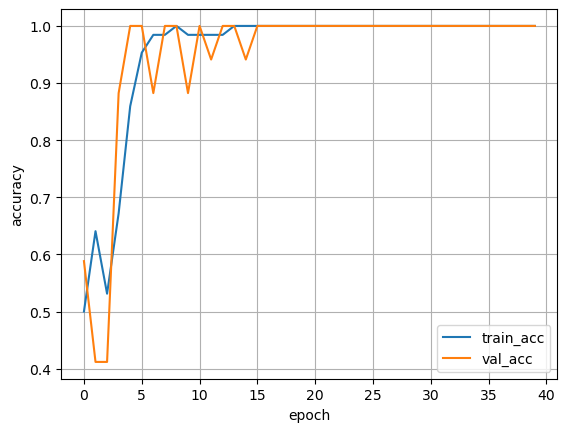

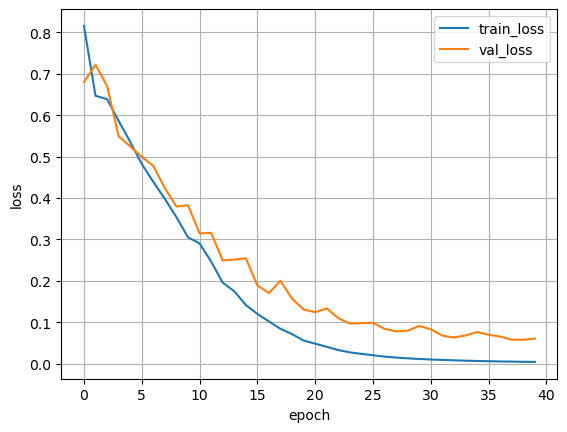

In [22]:
plt.figure()
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()


## 7. Быстрая проверка предсказаний на примерах из test

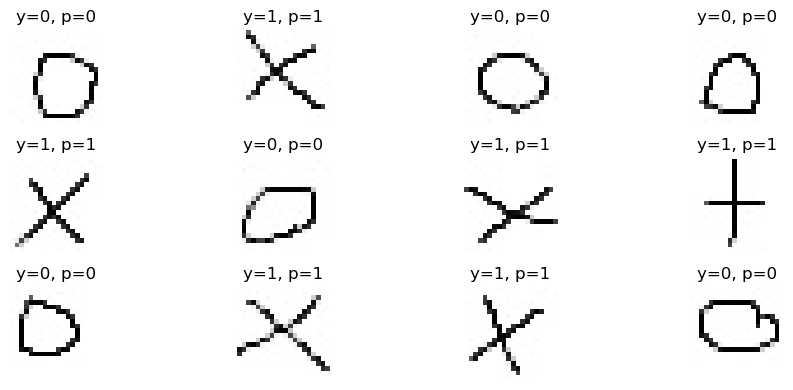

In [25]:
idx = np.random.choice(len(x_test), size=min(12, len(x_test)), replace=False)

proba = model.predict(x_test[idx], verbose=0).reshape(-1)
pred = (proba >= 0.5).astype(int)

imgs = (x_test[idx].reshape(-1, 20, 20) * 255).astype("uint8")

plt.figure(figsize=(10, 4))
for i in range(len(idx)):
    plt.subplot(3, 4, i+1)
    plt.imshow(imgs[i], cmap="gray")
    plt.axis("off")
    plt.title(f"y={y_test[idx[i]]}, p={pred[i]}")
plt.tight_layout()
plt.show()


In [27]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f} | Test loss: {test_loss:.4f}")

Test accuracy: 1.0000 | Test loss: 0.0468


In [29]:
acc_sample = (pred == y_test[idx]).mean()
print("Accuracy на выбранных 12 примерах:", acc_sample)

Accuracy на выбранных 12 примерах: 1.0
